## Evaluation Notebook

In [1]:
import joblib
import pandas as pd
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
print("Joblib version:", joblib.__version__)
print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pd.__version__)

Joblib version: 1.6.0
scikit-learn version: 1.6.1
pandas version: 3.0.5


In [3]:
# Import the joblib (startup model pipeline) and save it to a variable
model = joblib.load('startup_model_v1.joblib')

In [4]:
# Load the test data from the CSV file into a pandas DataFrame
df = pd.read_csv('data/startup_success_dataset.csv')

In [5]:
# Give me the shape and show me a visual of the table
print("rows:", df.shape[0], "\n"
      "columns:", df.shape[1])

df.head()

rows: 100000 
columns: 11


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [6]:
# Drop the target from the dataset and save it to a separate variable.
X = df.drop('outcome', axis = 1)
y = df['outcome']

In [7]:
# Split the data into training and testing sets. Stratify the split to make sure the class distribution between sets is always the same.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [8]:
# Make predictions on the test set
y_prediction = model.predict(X_test)

# Evaluate the model's performance by showing me a classification report.
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

 Acquisition       0.72      0.66      0.69      8467
     Failure       0.76      0.83      0.80     11122
         IPO       0.65      0.27      0.38       411

    accuracy                           0.74     20000
   macro avg       0.71      0.58      0.62     20000
weighted avg       0.74      0.74      0.74     20000



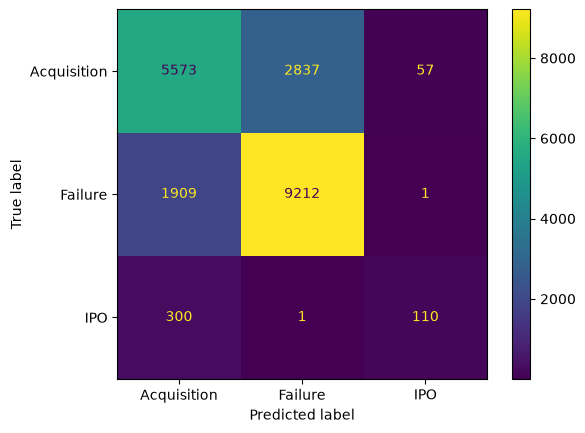

In [9]:
# Show me a confusion matrix of the model's predictions
ConfusionMatrixDisplay.from_predictions(y_test, y_prediction)

Roughly 99% of the missed IPO classifications are being classified as "Acquisition."
The question is, why? What's different between the True IPO feature values and the missed IPO outcomes being classified as "Acquisition" predictions?

In [10]:
# Make a copy of the test set. 
evaluation_df = X_test.copy()

In [11]:
# Add two new columns to the df copy. Columns include the actual test outcomes as well as the test predictions
evaluation_df['actual_outcome'] = y_test
evaluation_df['predicted_outcome'] = y_prediction

In [12]:
# Show me the new DataFrame
evaluation_df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,actual_outcome,predicted_outcome
9017,3,4,198,10.936169,308102,4.802882,5.037752e+05,angel,Ecommerce,first_time,Failure,Failure
32883,1,22,285,10.087045,405365,4.442152,1.677772e+06,tier1_vc,Climate,academic,Acquisition,Acquisition
83306,1,17,27,10.219264,677537,18.089276,2.073317e+06,tier2_vc,Climate,first_time,Acquisition,Acquisition
37680,2,6,275,4.793998,337558,19.524605,1.418060e+06,tier2_vc,Crypto,academic,Acquisition,Acquisition
16470,1,10,298,25.834650,365457,5.172814,7.989148e+05,tier2_vc,Climate,serial_founder,Acquisition,Failure


In [13]:
# Give me all the rows in the DataFrame where the actual outcome is IPO.
ipo_df = evaluation_df.query("actual_outcome == 'IPO'")

In [14]:
# Separate the predicted outcomes for IPO. Give me the IPO predictions in one variable and the Acquisition predictions in a separate variable.
correct_ipos = ipo_df.query("predicted_outcome == 'IPO'")
missed_ipos = ipo_df.query("predicted_outcome == 'Acquisition'")

In [15]:
numeric_features = [
    "funding_rounds",
    "founder_experience_years",
    "team_size",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]

In [16]:
# Show me the averages per feature across the Correct and Missed classifications. Are there any immediately identifiable differences?
ipo_comparison = pd.DataFrame({
    "Correct IPO": correct_ipos[numeric_features].mean(),
    "Missed IPO": missed_ipos[numeric_features].mean()
})

ipo_comparison

,Correct IPO,Missed IPO
funding_rounds,3.445455e+00,2.826667e+00
founder_experience_years,1.690909e+01,1.493333e+01
team_size,1.842091e+02,1.688200e+02
market_size_billion,2.997396e+01,3.268508e+01
product_traction_users,6.714872e+05,5.084531e+05
burn_rate_million,1.457017e+01,1.823300e+01
revenue_million,2.884624e+06,1.916808e+06


In [23]:
# Show me a DataFrame with all the actual IPO companies with predictions of Acquisition.
ipo_df.head().reset_index()

,index,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,actual_outcome,predicted_outcome
0,78105,4,9,18,37.684867,535557,8.061841,1.696157e+06,tier1_vc,Climate,academic,IPO,Acquisition
1,72026,3,13,222,6.000313,534375,6.630873,1.923810e+06,tier2_vc,AI,ex_bigtech,IPO,Acquisition
2,63206,4,2,89,37.884168,312795,48.440062,1.068116e+06,none,Climate,ex_bigtech,IPO,Acquisition
3,32692,0,22,39,43.976538,715998,14.415664,3.517595e+06,none,SaaS,first_time,IPO,IPO
4,49782,3,0,262,17.617110,530477,24.667179,2.391754e+06,tier2_vc,Fintech,academic,IPO,Acquisition


I chose a company from the above data table at index 2. It contains an actual outcome = IPO, and a prediction = Acquisition. The confidence score of this incorrect prediction = 84.9%.

Continuing EDA, I proceeded to run tests on the individual features that boasted higher variance produced in the 'ipo_comparison' DataFrame.

The goal was to understand which of the features with high variance influence the model most. Based on my initial manual tests, "revenue_million" had the most influence on the model. Increasing the company's revenue value from ~$1.7M to $3.55M altered the outcome (and confidence score) from an incorrect Acquisition outcome to a correct prediction of IPO with a 50.% confidence score. At the maximum allowable revenue value ($4M), the confidence score increases to 69.8% IPO. No other feature manipulation led to a correct prediction. 

Continuing this EDA, the below code programmatically generates confidence/probability scores for all 300 companies that have an actual outcome = IPO but a predicted outcome = Acquisition.

With this information, I plan to understand the percentage of the examined companies carrying an incorrect confidence score greater than 80%.

In [30]:
# Get a new DataFrame with IPO companies that only have the predicted outcome == "Acquisition"
pred_acquisition_df = missed_ipos.copy()

In [33]:
# Remove the actual_outcome and predicted_outcome columns so the DataFrame can be fed to model.joblib
X_pred_acquisition_df = pred_acquisition_df.drop(
    columns = ["actual_outcome", "predicted_outcome"]
)

In [34]:
# Feed the new DataFrame to the model joblib
probabilities = model.predict_proba(X_pred_acquisition_df)

In [36]:
print(model.classes_)

['Acquisition' 'Failure' 'IPO']


In [49]:
# Tell me how many of the acquisition predictions have a confidence score >= 80%.
high_confidence_misses = pred_acquisition_df.query(
    "acquisition_probability >= .80"
)

print("Number of incorrect Acquisition predictions with a confidence score higher than 80%:", len(high_confidence_misses))

Number of incorrect Acquisition predictions with a confidence score higher than 80%: 137


In [66]:
# Based on the number above, give me the percentage.
print(f"{len(high_confidence_misses) / len(pred_acquisition_df):.2%}")

45.67%


45.67% of the IPO companies that were incorrectly predicted as Acquisition have a confidence score > 80%.